# Análise Exploratória Inicial

### Visão Geral e Cardinalidade

Esta etapa permite uma visão exaustiva da distribuição dos dados. A análise de todas as entidades é essencial para identificar quais clientes ou servidores possuem amostras insuficientes para a aplicação de algoritmos de CPD, permitindo uma filtragem fundamentada antes da modelagem.

Total de medições: 432104
Total de clientes distintos: 21
Total de servidores distintos: 40
Total de pares cliente-servidor distintos: 523
Tipos de dispositivos: ['raspberry' 'router' 'pc']


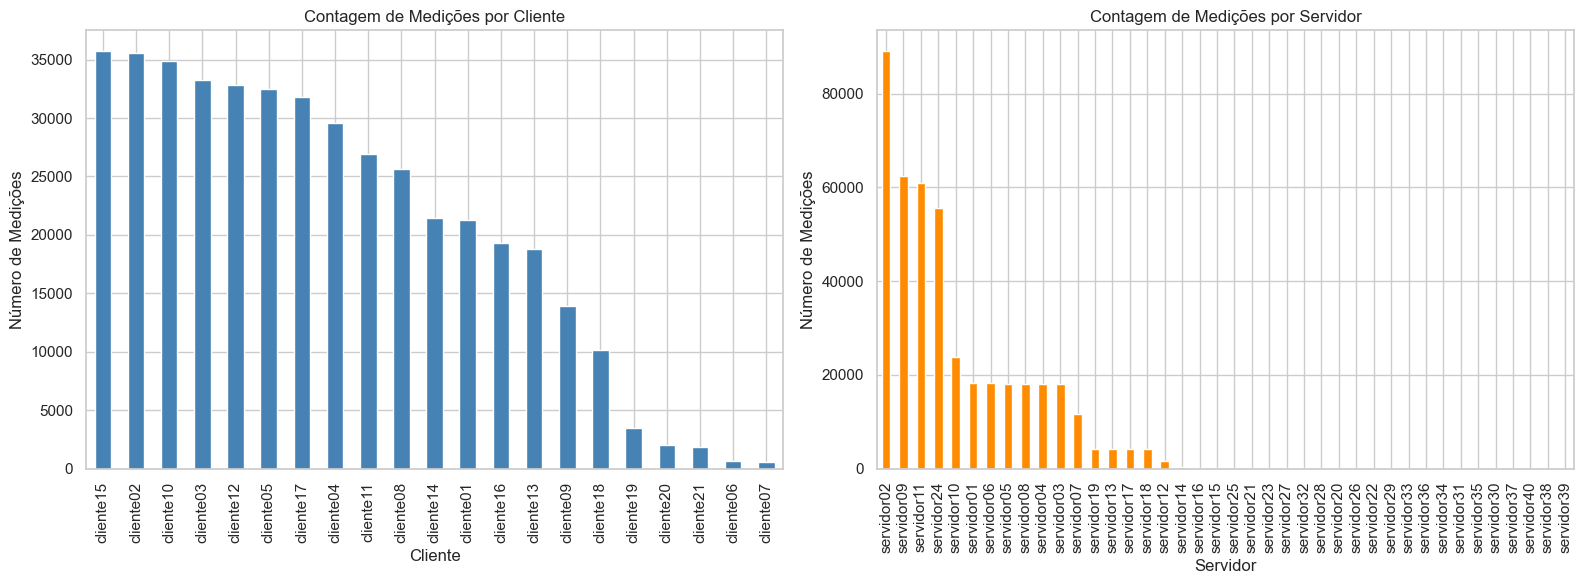

In [20]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import json


# Carregamento do dataset
file = 'NDT_transformed.csv'
# file = 'NDT_clean.csv'
file_path = os.path.join("NDT dataset", file)
df = pd.read_csv(file_path)

# # Unificar os servidores dos sites do MLAB
# df['server_name'] = df['server_name'].str.replace(r'MLAB[1-3]-(.*)', r'MLAB-\1', regex=True)

# abreviar para só Computador Curi
df['client_name'] = df['client_name'].str.replace(r'Computador Curi.*', 'Computador Curi', regex=True)

# Anonimizar client_name e server_name
with open(os.path.join("NDT dataset", "mapping_log.json"), "r", encoding="utf-8") as f:
    mapping = json.load(f)
inv_client_map = {v: k for k, v in mapping["client_map"].items()}
inv_server_map = {v: k for k, v in mapping["server_map"].items()}
df["client_name"] = df["client_name"].map(inv_client_map).fillna(df["client_name"])
df["server_name"] = df["server_name"].map(inv_server_map).fillna(df["server_name"])

# Criar coluna de par cliente-servidor
df['client_server_pair'] = df['client_name'] + " -> " + df['server_name']

# Conversão de timestamp
df['timestamp'] = pd.to_datetime(df['timestamp'])
df['data'] = df['timestamp'].dt.date

# Ordenar por tempo e par
df = df.sort_values(by=['client_server_pair', 'timestamp']).reset_index(drop=True)

# Criar coluna com a diferença de tempo
df['delta_tempo_horas'] = df.groupby('client_server_pair')['timestamp'].diff().dt.total_seconds() / 3600

# Contagens Gerais
total_medicoes = len(df)
num_clientes = df['client_name'].nunique()
num_servidores = df['server_name'].nunique()
num_pares = df['client_server_pair'].nunique()
tipos = df['tipo'].unique()

print(f"Total de medições: {total_medicoes}")
print(f"Total de clientes distintos: {num_clientes}")
print(f"Total de servidores distintos: {num_servidores}")
print(f"Total de pares cliente-servidor distintos: {num_pares}")
print(f"Tipos de dispositivos: {tipos}")

# Distribuição por Cliente e Servidor
medicoes_por_cliente = df['client_name'].value_counts()
medicoes_por_servidor = df['server_name'].value_counts()

# Plotagem em Gráficos de Barras
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico de Clientes
medicoes_por_cliente.plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Contagem de Medições por Cliente')
axes[0].set_ylabel('Número de Medições')
axes[0].set_xlabel('Cliente')
axes[0].tick_params(axis='x', rotation=90)

# Gráfico de Servidores
medicoes_por_servidor.plot(kind='bar', ax=axes[1], color='darkorange')
axes[1].set_title('Contagem de Medições por Servidor')
axes[1].set_ylabel('Número de Medições')
axes[1].set_xlabel('Servidor')
axes[1].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

### Verificação de Valores Nulos e Negativos

Esta etapa visa identificar a presença de dados faltantes (nulos) e valores numéricos inconsistentes, como registros negativos em métricas de rede que devem ser estritamente positivas (throughput, latência e taxa de perda). A detecção prévia destas anomalias é indispensável para garantir a integridade da série temporal e evitar distorções matemáticas durante a aplicação do algoritmo de *Changepoint Detection*.


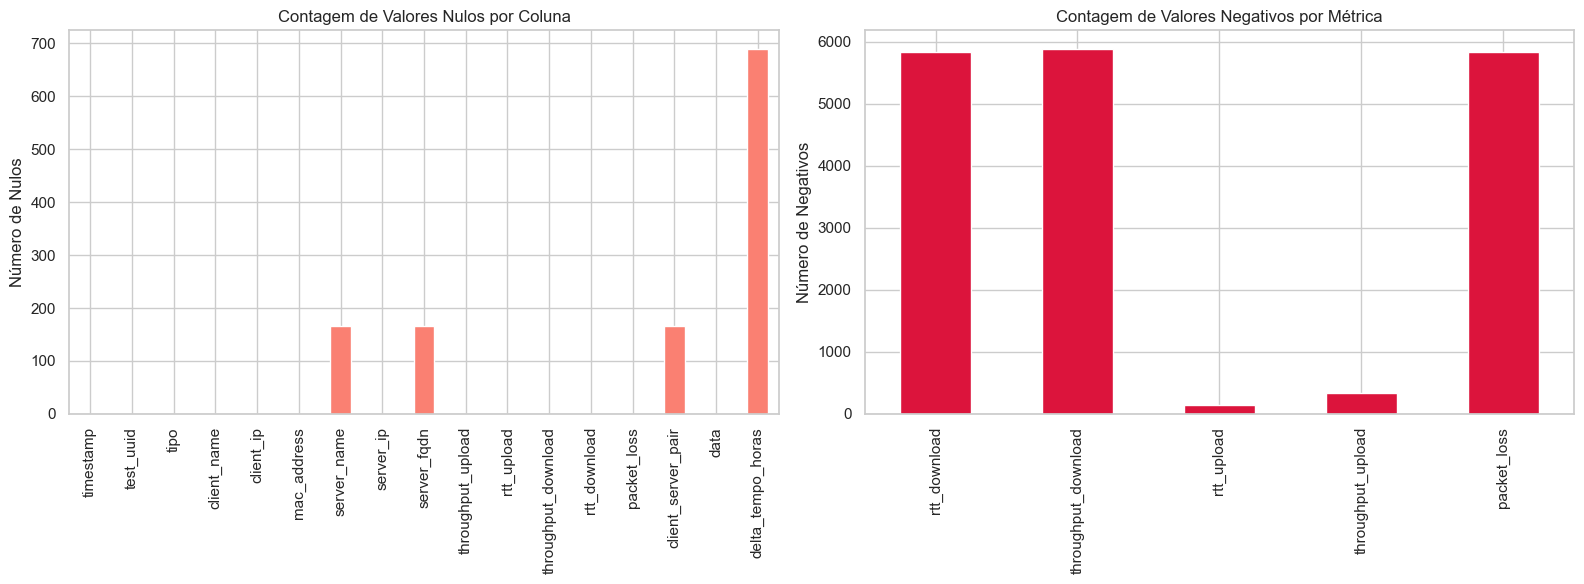

In [21]:
import matplotlib.pyplot as plt
import pandas as pd

nulos = df.isnull().sum()

metricas = [
    'rtt_download', 'throughput_download', 
    'rtt_upload', 'throughput_upload', 'packet_loss'
]
negativos = {col: (df[col] < 0).sum() for col in metricas if col in df.columns}
negativos_series = pd.Series(negativos)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

nulos.plot(kind='bar', ax=axes[0], color='salmon')
axes[0].set_title('Contagem de Valores Nulos por Coluna')
axes[0].set_ylabel('Número de Nulos')
axes[0].tick_params(axis='x', rotation=90)

negativos_series.plot(kind='bar', ax=axes[1], color='crimson')
axes[1].set_title('Contagem de Valores Negativos por Métrica')
axes[1].set_ylabel('Número de Negativos')
axes[1].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

### Verificação de Pares Cliente-Servidor

Esta etapa quantifica as combinações únicas de clientes e servidores presentes no dataset. O objetivo é identificar o número total de fluxos de comunicação distintos antes de prosseguir com a análise de distribuição temporal e avaliação de constância para cada par.

Total de pares cliente-servidor distintos: 523


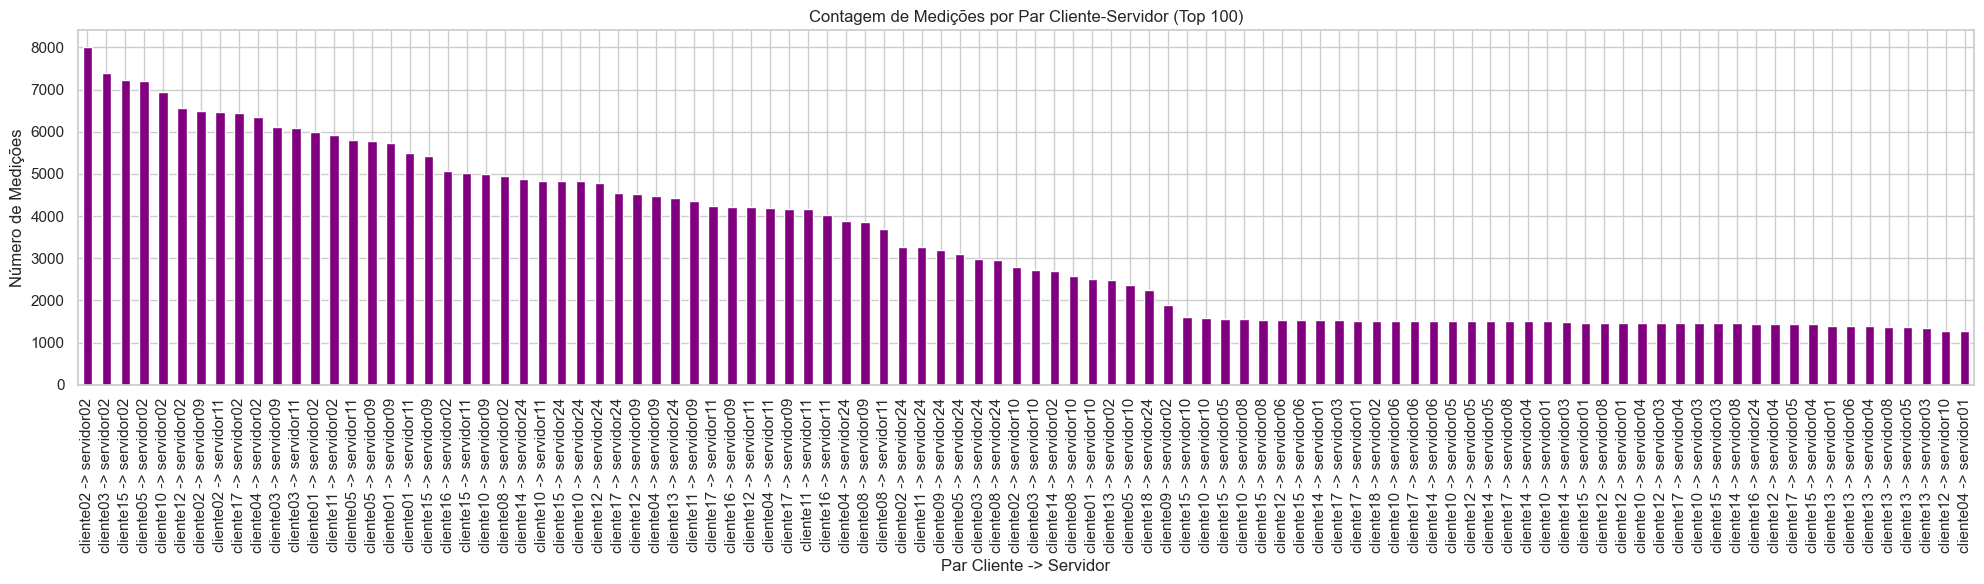

In [22]:
num_pares = df['client_server_pair'].nunique()
print(f"Total de pares cliente-servidor distintos: {num_pares}")

medicoes_por_par = df['client_server_pair'].value_counts()

# filtrar pelos 30 pares mais comuns
medicoes_por_par = medicoes_por_par.head(100)

import matplotlib.pyplot as plt

plt.figure(figsize=(20, 6))
medicoes_por_par.plot(kind='bar', color='purple')
plt.title(f'Contagem de Medições por Par Cliente-Servidor (Top {len(medicoes_por_par)})')
plt.xlabel('Par Cliente -> Servidor')
plt.ylabel('Número de Medições')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

### Verificação de Timestamps Duplicados

Em análises de séries temporais e, especialmente, na aplicação de algoritmos de *Changepoint Detection* (CPD), a unicidade do índice de tempo para cada fluxo é um pré-requisito matemático rigoroso. A presença de *timestamps* duplicados para um mesmo par Cliente-Servidor indica que múltiplas medições foram registradas no exato mesmo instante, o que pode causar falhas em janelas móveis (*rolling windows*), cálculos de variância e quebrar a execução de rotinas de exportação ou modelagem. Esta etapa quantifica essas ocorrências.

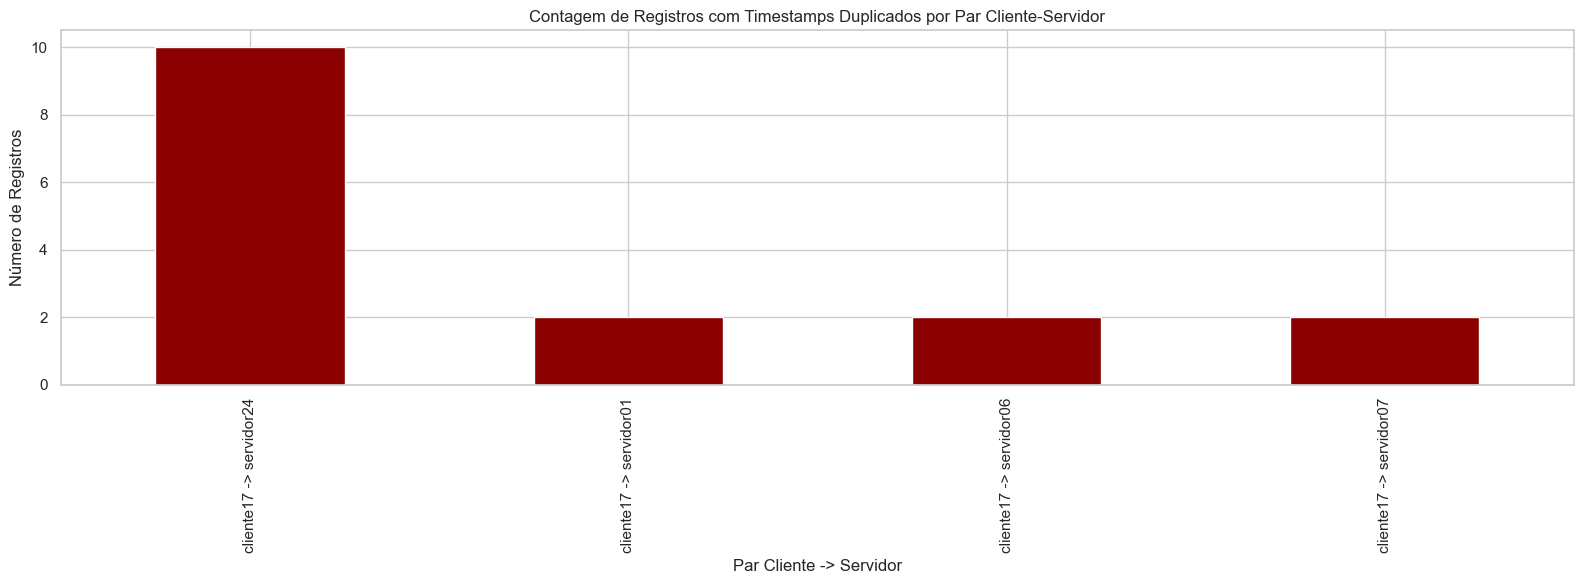

RESUMO DE DUPLICATAS
Total de pares com registros colidindo: 4
Total absoluto de linhas duplicadas:    16
Total de UUIDs únicos colidindo:        16
------------------------------------------------------------

Distribuição por par:
cliente17 -> servidor01: 2 registros colidindo
cliente17 -> servidor06: 2 registros colidindo
cliente17 -> servidor07: 2 registros colidindo
cliente17 -> servidor24: 10 registros colidindo
------------------------------------------------------------

Pares com mais de 1 registro colidindo (Medições únicas):
cliente17 -> servidor01: 1523 medições únicas
cliente17 -> servidor06: 1517 medições únicas
cliente17 -> servidor07: 981 medições únicas
cliente17 -> servidor24: 4552 medições únicas


In [23]:
import matplotlib.pyplot as plt

# Identificação das duplicatas
duplicatas = df.duplicated(subset=['client_server_pair', 'timestamp'], keep=False)
df_duplicadas = df[duplicatas].sort_values(by=['client_server_pair', 'timestamp']).dropna()
uuids_duplicados = df_duplicadas['test_uuid'].unique()

# Agregação e resumo
pares_com_duplicatas = df_duplicadas.groupby('client_server_pair').size()
nomes_pares = pares_com_duplicatas[pares_com_duplicatas > 1].index.tolist()

# Visualização Gráfica
if pares_com_duplicatas.empty:
    print("Nenhum par Cliente-Servidor possui timestamps duplicados.")
else:
    plt.figure(figsize=(16, 6))
    pares_com_duplicatas.sort_values(ascending=False).plot(kind='bar', color='darkred')
    plt.title('Contagem de Registros com Timestamps Duplicados por Par Cliente-Servidor')
    plt.xlabel('Par Cliente -> Servidor')
    plt.ylabel('Número de Registros')
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()

# 5. Print organizado (Refinado conforme seu pedido)
print("="*60)
print(f"RESUMO DE DUPLICATAS")
print("="*60)
print(f"Total de pares com registros colidindo: {len(pares_com_duplicatas)}")
print(f"Total absoluto de linhas duplicadas:    {len(df_duplicadas)}")
print(f"Total de UUIDs únicos colidindo:        {len(uuids_duplicados)}")
print("-"*60)

print("\nDistribuição por par:")
for par, qtd in pares_com_duplicatas.items():
    print(f"{par}: {qtd} registros colidindo")

print("-"*60)
print("\nPares com mais de 1 registro colidindo (Medições únicas):")
for par in nomes_pares:
    total = df[df['client_server_pair'] == par]['test_uuid'].nunique()
    print(f"{par}: {total} medições únicas")
print("="*60)

In [24]:
# Printar cada par com seus timestamps duplicados
print("\nDetalhes dos pares com timestamps duplicados:")
timestamps_duplicados = df_duplicadas['timestamp'].unique()
for par in nomes_pares:
    print(f"\nPar: {par}")
    df_par = df_duplicadas[df_duplicadas['client_server_pair'] == par]
    for timestamp in timestamps_duplicados:
        df_timestamp = df_par[df_par['timestamp'] == timestamp]
        if not df_timestamp.empty:
            print(f"  Timestamp: {timestamp} - Registros: {len(df_timestamp)}")


Detalhes dos pares com timestamps duplicados:

Par: cliente17 -> servidor01
  Timestamp: 2025-10-25 03:40:37+00:00 - Registros: 2

Par: cliente17 -> servidor06
  Timestamp: 2025-10-27 06:44:23+00:00 - Registros: 2

Par: cliente17 -> servidor07
  Timestamp: 2025-10-25 03:40:37+00:00 - Registros: 2

Par: cliente17 -> servidor24
  Timestamp: 2025-10-25 03:40:37+00:00 - Registros: 2
  Timestamp: 2025-10-27 06:44:23+00:00 - Registros: 2
  Timestamp: 2025-10-25 04:19:37+00:00 - Registros: 2
  Timestamp: 2025-10-25 04:58:33+00:00 - Registros: 2
  Timestamp: 2025-10-27 13:01:20+00:00 - Registros: 2


### Contagem de medições ao longo do tempo

Esta etapa realiza a contagem diária da quantidade de servidores únicos, clientes ativos e do volume total de testes. A visualização simultânea dessas três métricas permite acompanhar o comportamento da infraestrutura ao longo do tempo e identificar visualmente anomalias, como quedas bruscas no fluxo de dados.

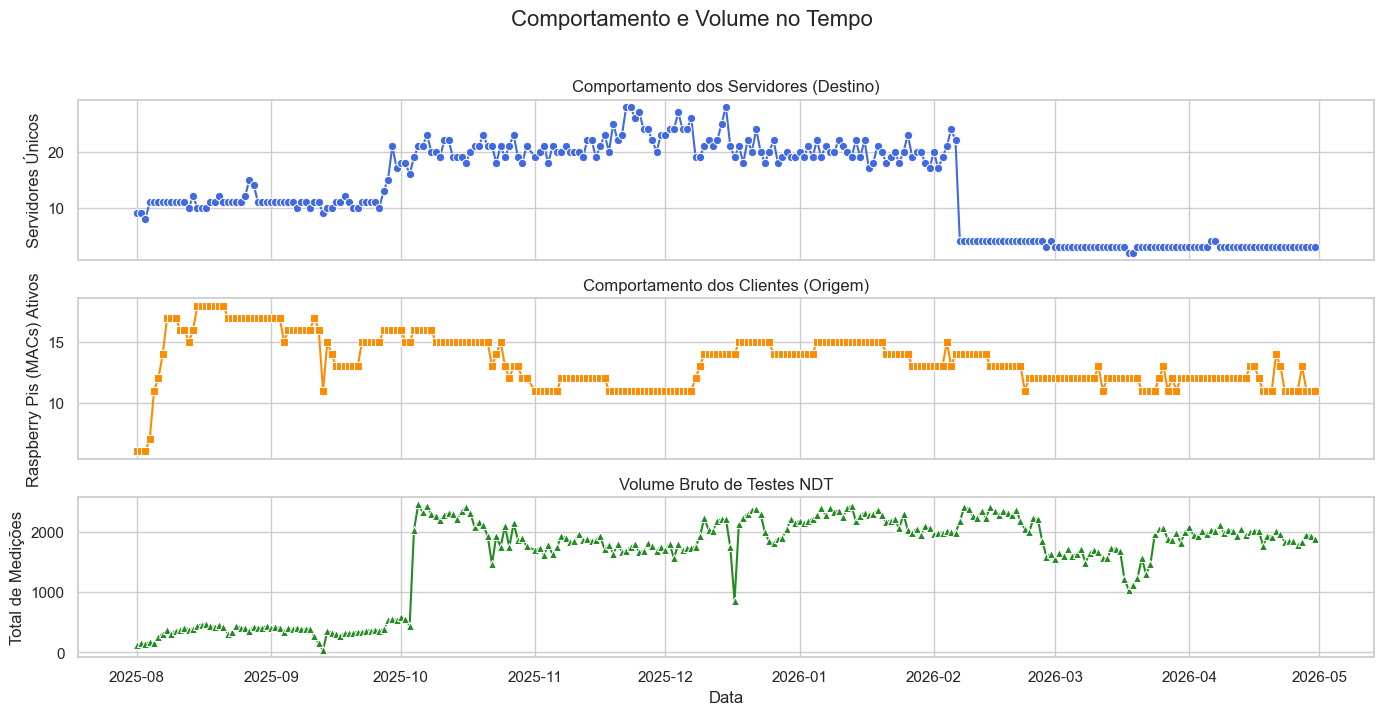

In [25]:
import seaborn as sns
# Agrupa por dia contando servidores, clientes(MACs) e volume total de testes
analise_drop = df.groupby('data').agg(
    qtd_servidores=('server_name', 'nunique'),
    qtd_clientes=('client_name', 'nunique'),
    total_testes=('timestamp', 'count')
).reset_index()

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(3, 1, figsize=(14, 7), sharex=True)
fig.suptitle('Comportamento e Volume no Tempo', fontsize=16, y=1.02)

# Gráfico 1: Servidores (O que você já viu)
sns.lineplot(data=analise_drop, x='data', y='qtd_servidores', ax=axes[0], color='royalblue', marker='o')
axes[0].set_ylabel('Servidores Únicos')
axes[0].set_title('Comportamento dos Servidores (Destino)')

# Gráfico 2: Clientes (A possível causa)
sns.lineplot(data=analise_drop, x='data', y='qtd_clientes', ax=axes[1], color='darkorange', marker='s')
axes[1].set_ylabel('Raspberry Pis (MACs) Ativos')
axes[1].set_title('Comportamento dos Clientes (Origem)')

# Gráfico 3: Volume Total de Medições
sns.lineplot(data=analise_drop, x='data', y='total_testes', ax=axes[2], color='forestgreen', marker='^')
axes[2].set_ylabel('Total de Medições')
axes[2].set_xlabel('Data')
axes[2].set_title('Volume Bruto de Testes NDT')

plt.tight_layout()
plt.show()

### Análise de Constância e Lacunas Temporais

Esta visualização utiliza um gráfico de dispersão (*scatter plot*) para avaliar a constância das medições ao longo do tempo. O eixo X representa a linha do tempo (do registro mais antigo ao mais recente) e o eixo Y lista cada par único de Cliente-Servidor. Cada ponto no gráfico corresponde a uma medição, permitindo a identificação visual de "buracos" — períodos prolongados sem coleta de dados para um determinado par —, o que é crucial para avaliar a continuidade da série temporal antes da aplicação de algoritmos de detecção de *changepoints*.

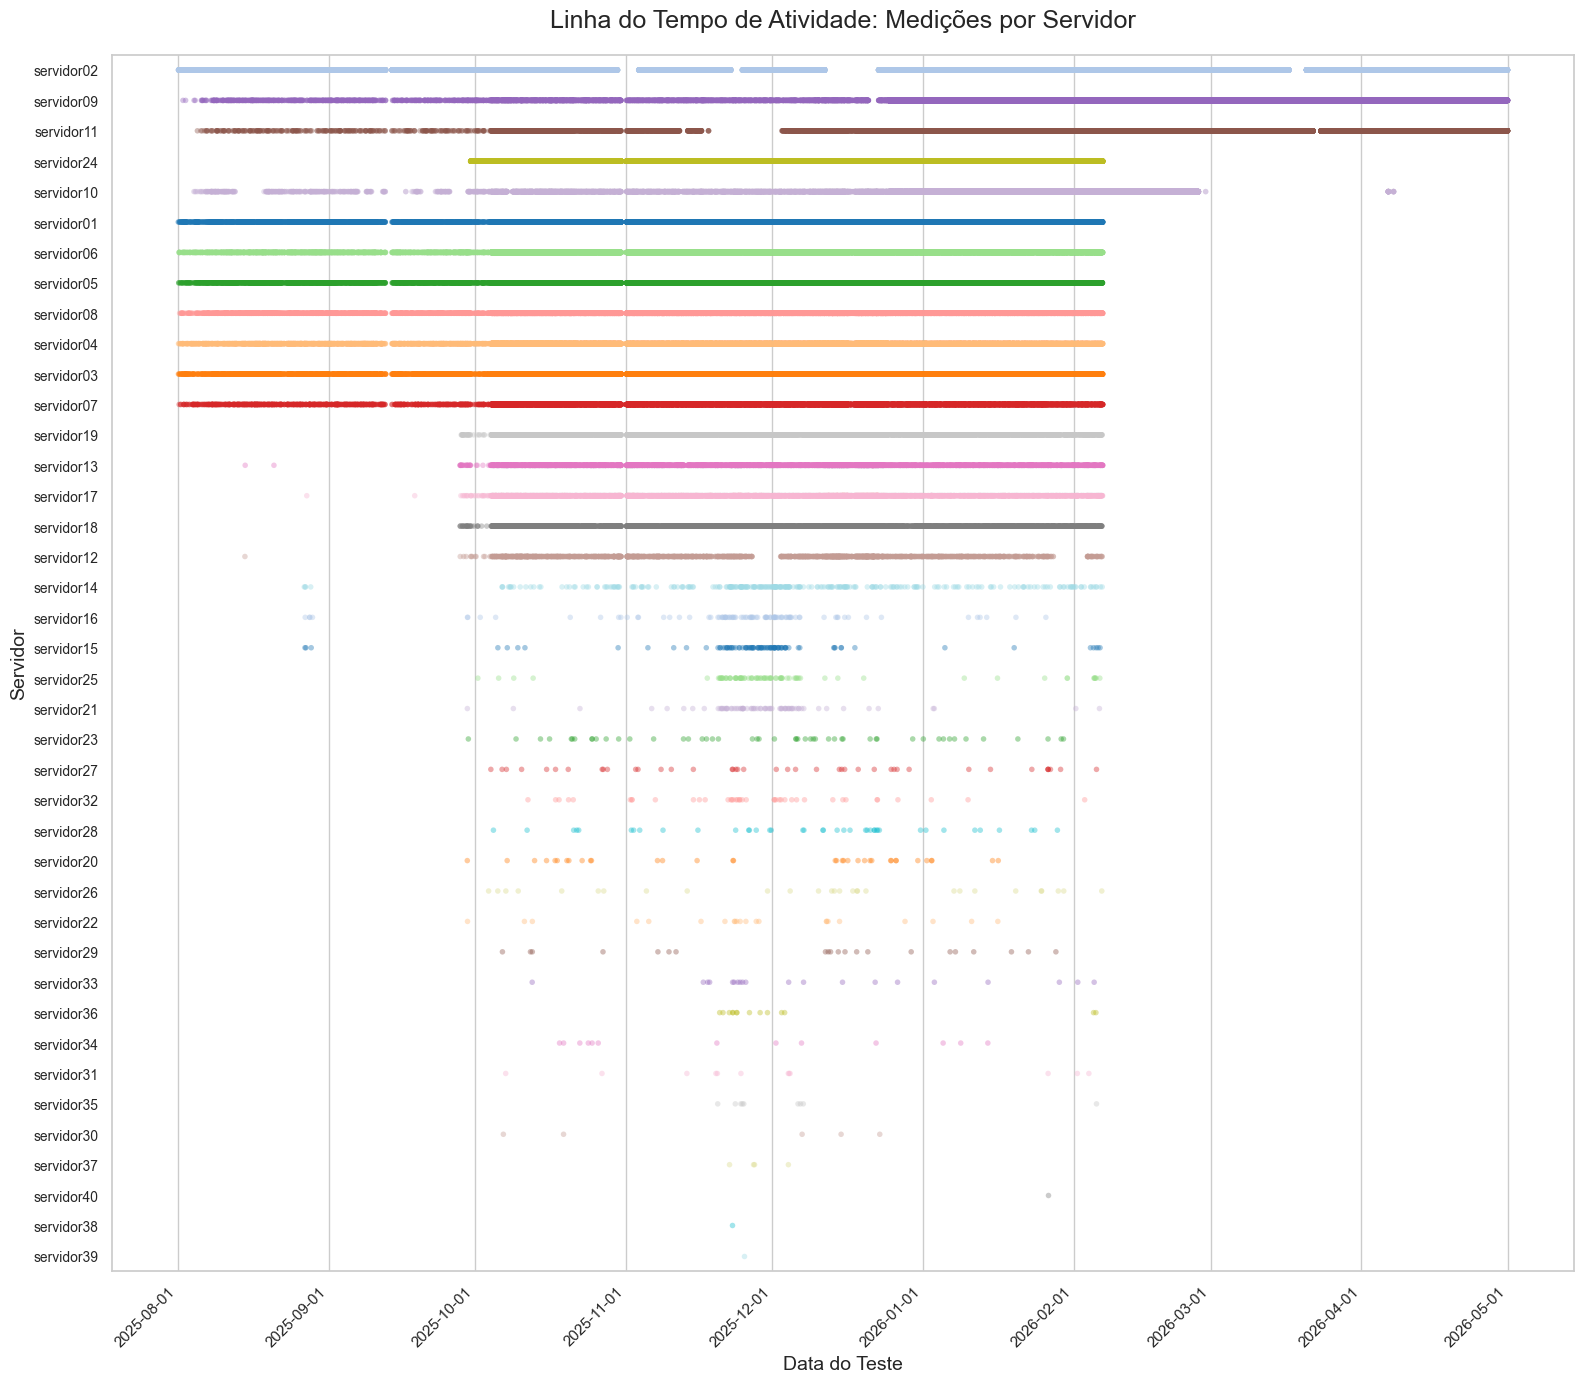

In [26]:
# Cria a lista com os servidores ordenados pelo volume de uso
ordem_servidores = df['server_name'].value_counts().sort_values(ascending=False).index

sns.set_theme(style="whitegrid")
plt.figure(figsize=(16, 14))

# Usando STRIPPLOT (O gráfico correto para isso)
sns.stripplot(
    data=df,
    x='timestamp', 
    y='server_name',
    hue='server_name',
    palette='tab20',
    size=4,             # No stripplot, o tamanho é 'size' (em vez de 's')
    alpha=0.4,
    legend=False,
    order=ordem_servidores, # Aqui a ordenação funciona!
    jitter=False        # Desliga o espalhamento para os pontos formarem uma linha reta
)

plt.title('Linha do Tempo de Atividade: Medições por Servidor', fontsize=18, pad=20)
plt.xlabel('Data do Teste', fontsize=14)
plt.ylabel('Servidor', fontsize=14)

import matplotlib.dates as mdates
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(fontsize=10)

plt.tight_layout()
plt.show()

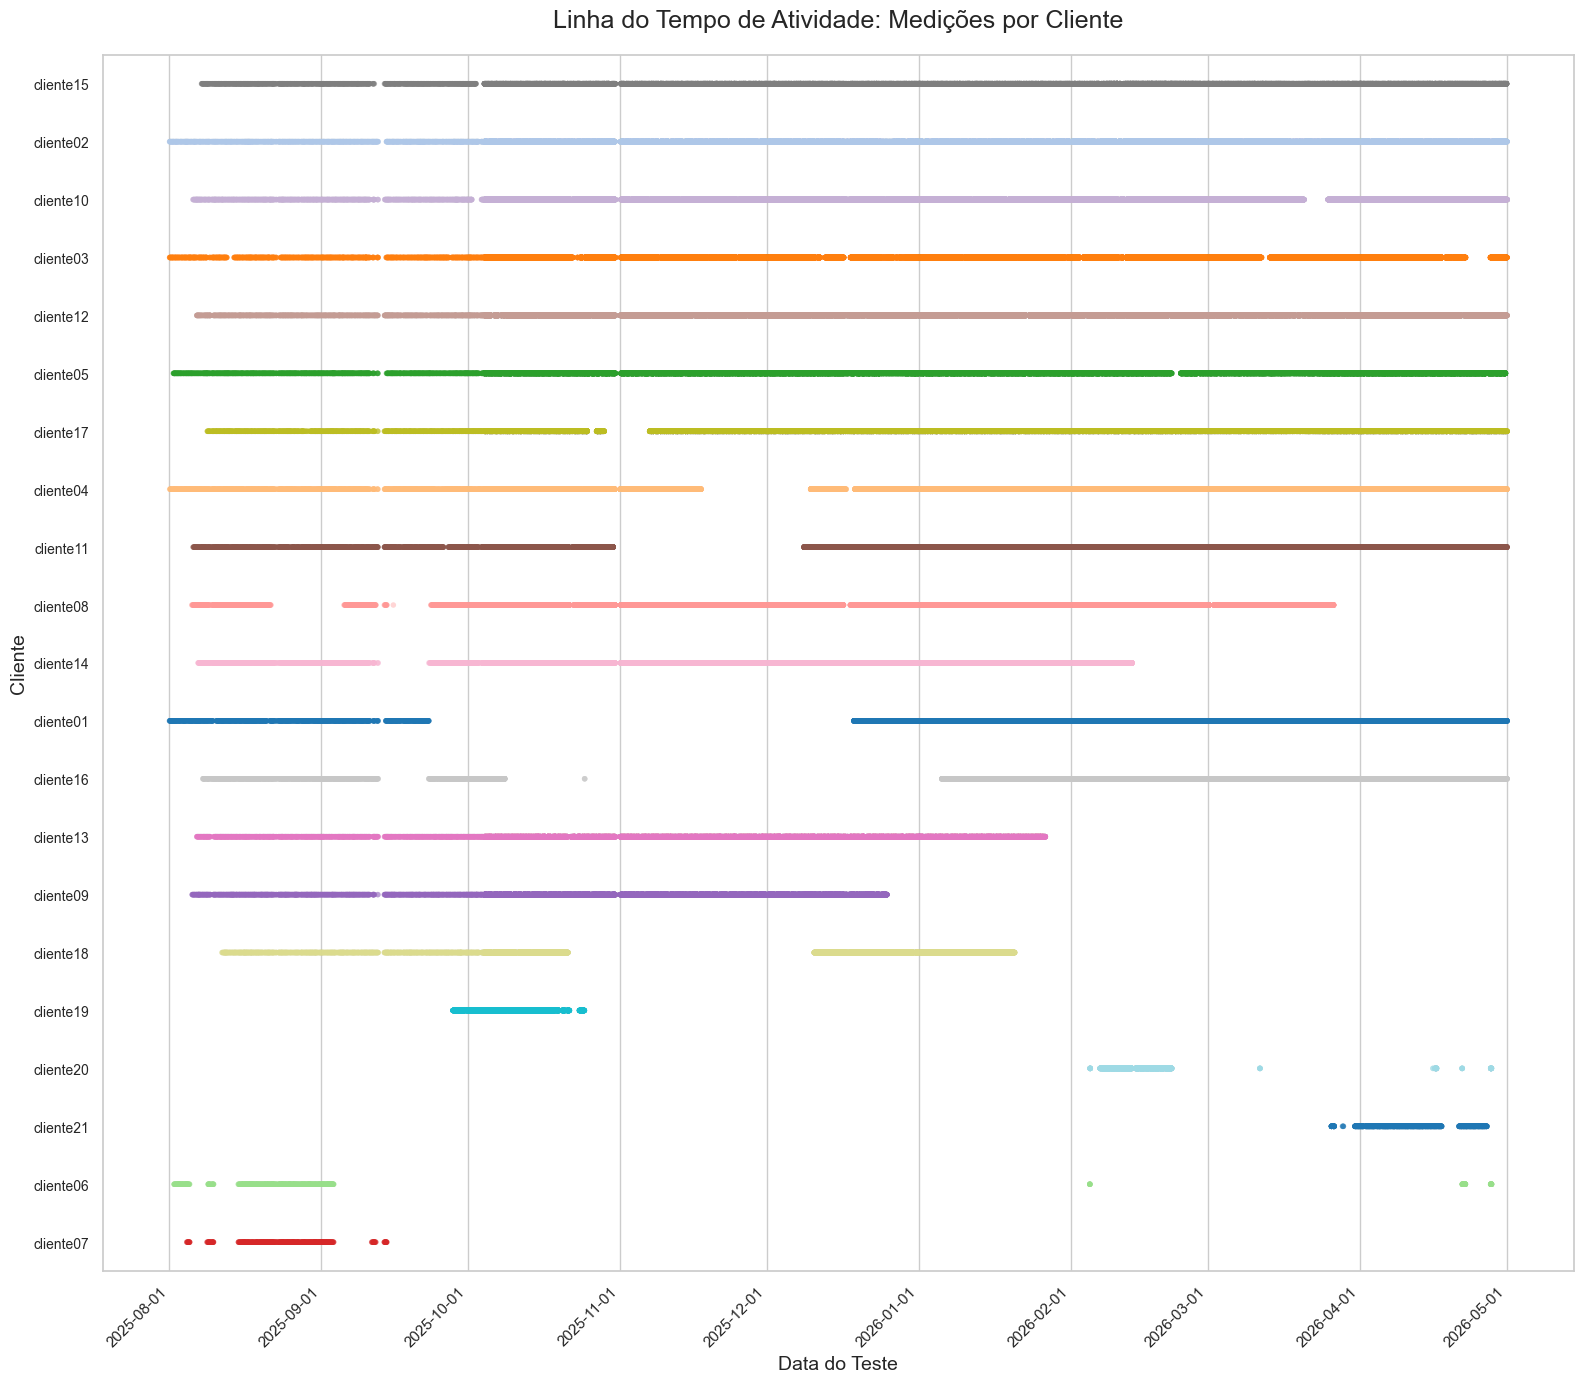

In [27]:
# Cria a lista com os clientes ordenados pelo volume de uso
ordem_clientes = df['client_name'].value_counts().sort_values(ascending=False).index

sns.set_theme(style="whitegrid")
plt.figure(figsize=(16, 14))

# Usando STRIPPLOT (O gráfico correto para isso)
sns.stripplot(
    data=df,
    x='timestamp', 
    y='client_name',
    hue='client_name',
    palette='tab20',
    size=4,             # No stripplot, o tamanho é 'size' (em vez de 's')
    alpha=0.4,
    legend=False,
    order=ordem_clientes, # Aqui a ordenação funciona!
    jitter=False        # Desliga o espalhamento para os pontos formarem uma linha reta
)

plt.title('Linha do Tempo de Atividade: Medições por Cliente', fontsize=18, pad=20)
plt.xlabel('Data do Teste', fontsize=14)
plt.ylabel('Cliente', fontsize=14)

import matplotlib.dates as mdates
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(fontsize=10)

plt.tight_layout()
plt.show()

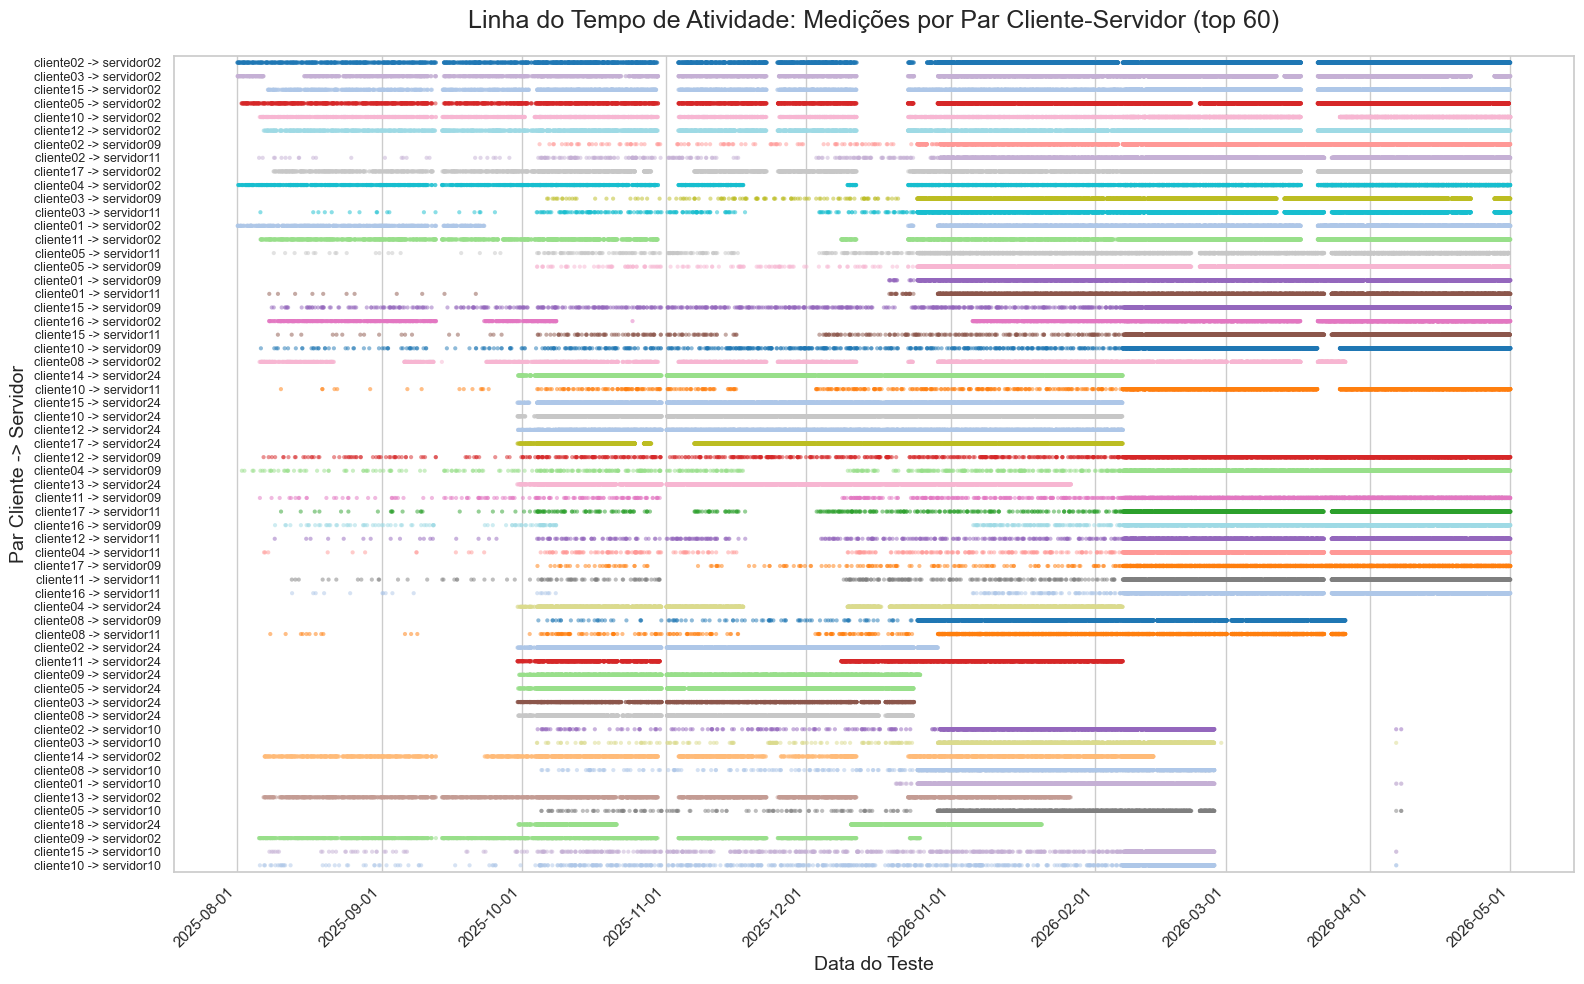

In [28]:
# Cria a lista com os 50 PARES como maior volume de uso
ordem_pares = df['client_server_pair'].value_counts().sort_values(ascending=False).index
ordem_pares = df['client_server_pair'].value_counts().index[:60]

sns.set_theme(style="whitegrid")
plt.figure(figsize=(16, 10)) # Aumentei a altura para acomodar os pares

# Usando STRIPPLOT por Par
sns.stripplot(
    data=df,
    x='timestamp',
    y='client_server_pair',
    hue='client_server_pair',
    palette='tab20',
    size=3,
    alpha=0.5,
    legend=False,
    order=ordem_pares,
    jitter=False,
)

plt.title(f'Linha do Tempo de Atividade: Medições por Par Cliente-Servidor (top {len(ordem_pares)})', fontsize=18, pad=20)
plt.xlabel('Data do Teste', fontsize=14)
plt.ylabel('Par Cliente -> Servidor', fontsize=14)

# Formatação do eixo X (Tempo)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(fontsize=9)

plt.tight_layout()
plt.show()

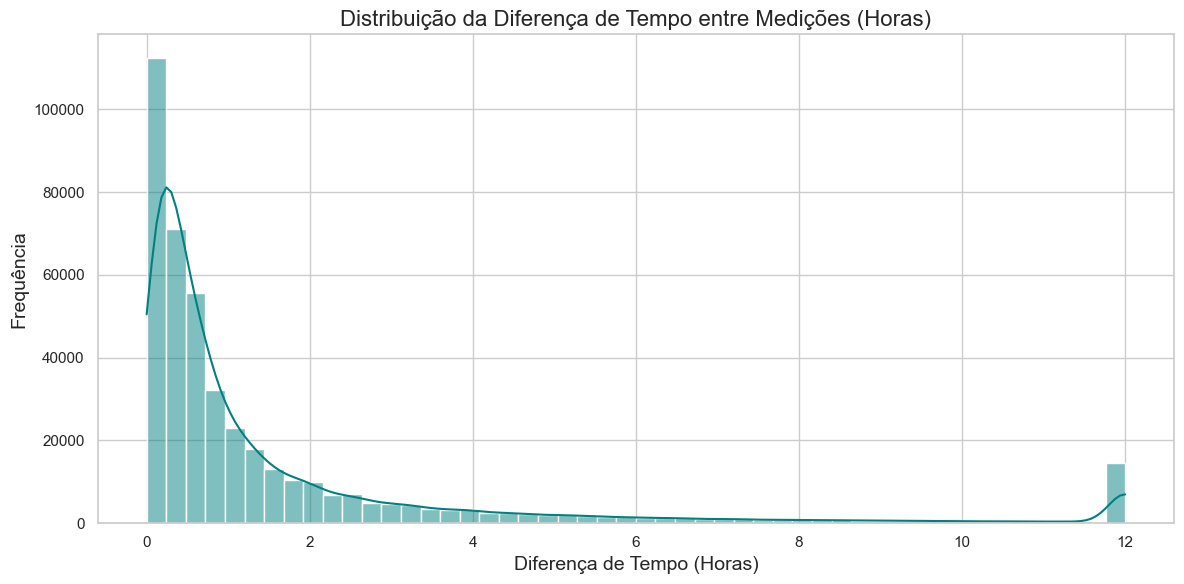

In [29]:
df_hist = df['delta_tempo_horas'].copy().dropna()

# clip para evitar outliers extremos
lower_bound = 0
upper_bound = 12
df_hist = df_hist.clip(lower=lower_bound, upper=upper_bound)

# histograma da diferença de tempo entre medições para o dataset todo
plt.figure(figsize=(12, 6))
sns.histplot(df_hist, bins=50, kde=True, color='teal')
plt.title('Distribuição da Diferença de Tempo entre Medições (Horas)', fontsize=16)
plt.xlabel('Diferença de Tempo (Horas)', fontsize=14)
plt.ylabel('Frequência', fontsize=14)
plt.tight_layout()
plt.show()

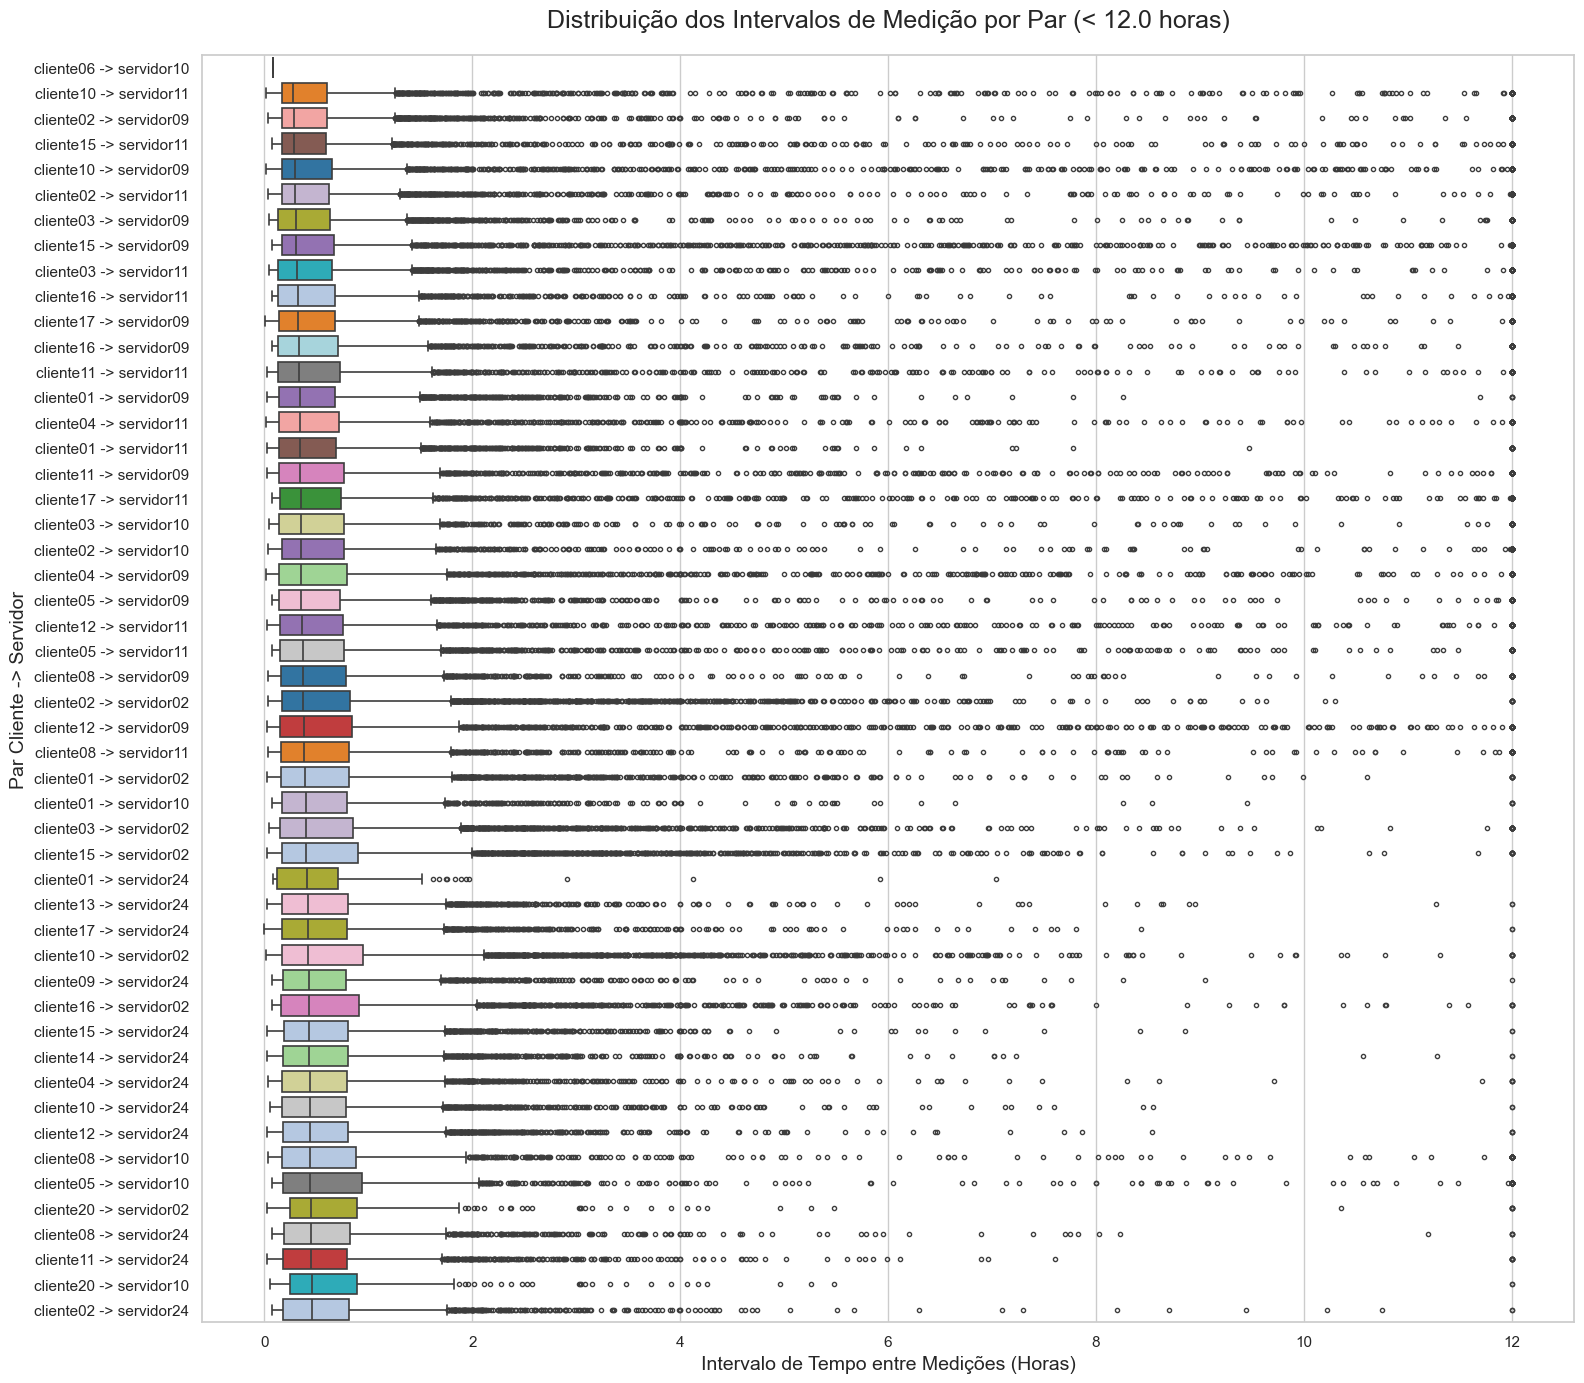

In [30]:
# rdenar o gráfico pela mediana do intervalo para melhor visualização
ordem_pares = df.groupby('client_server_pair')['delta_tempo_horas'].median().sort_values().index
ordem_pares = ordem_pares[:50] # Focar nos 50 pares com maior mediana de intervalo

#criar copia do dataframe para plotagem
df_intervalos = df.copy()

# clipar os valores de delta_tempo_horas em 1 e 99 percentil
lim_inf = 0
lim_sup = 12.0
df_intervalos['delta_tempo_horas'] = df_intervalos['delta_tempo_horas'].clip(lower=lim_inf, upper=lim_sup)


# Plotar o boxplot
sns.set_theme(style="whitegrid")
plt.figure(figsize=(16, 14))

sns.boxplot(
    data=df_intervalos,
    y='client_server_pair',
    x='delta_tempo_horas',
    hue='client_server_pair', 
    legend=False,             
    order=ordem_pares,
    palette='tab20',
    fliersize=3,
    linewidth=1.2
)

plt.title(f'Distribuição dos Intervalos de Medição por Par (< {lim_sup} horas)', fontsize=18, pad=20)
plt.xlabel('Intervalo de Tempo entre Medições (Horas)', fontsize=14)
plt.ylabel('Par Cliente -> Servidor', fontsize=14)

plt.tight_layout()
plt.show()

### Limpeza de dados (após análise)

In [31]:
# 1. Filtro de tipo e Dropna (em todas as colunas existentes até aqui)
df_clean = df[df['tipo'] == 'raspberry'].copy()
df_clean = df_clean.dropna()

# 2. Filtro de métricas negativas
metricas = ['rtt_download', 'throughput_download', 'rtt_upload', 'throughput_upload', 'packet_loss']
for col in metricas:
    if col in df_clean.columns:
        df_clean = df_clean[df_clean[col] >= 0]

# 3. Criar par e converter timestamp
df_clean['client_server_pair'] = df_clean['client_name'] + " -> " + df_clean['server_name']
df_clean['timestamp'] = pd.to_datetime(df_clean['timestamp'], utc=True)

# 4. Remover duplicatas ANTES de qualquer lógica de tempo (Crucial)
duplicatas = df_clean.duplicated(subset=['client_server_pair', 'timestamp'], keep=False)
df_clean = df_clean[~duplicatas].copy()

# 5. Ordenar (A função faz isso antes de filtrar data e calcular delta)
df_clean = df_clean.sort_values(by=['client_server_pair', 'timestamp']).reset_index(drop=True)

# 6. Filtro de data (Exatamente como na função)
data_inicio = pd.to_datetime('2025-10-04', utc=True)
df_clean = df_clean[df_clean['timestamp'] >= data_inicio].copy()

# 7. Cálculo do Delta (Feito após a limpeza e filtro de data na função)
df_clean['delta_tempo_horas'] = df_clean.groupby('client_server_pair')['timestamp'].diff().dt.total_seconds() / 3600

# 8. Lógica de blocos
limite_horas = 12.0
seg_min = 300

condicao_quebra = df_clean['delta_tempo_horas'] > limite_horas
df_clean['id_bloco'] = condicao_quebra.groupby(df_clean['client_server_pair']).cumsum()
df_clean['tamanho_bloco'] = df_clean.groupby(['client_server_pair', 'id_bloco'])['id_bloco'].transform('count')

# 9. Filtro de tamanho e Rank denso
df_clean = df_clean[df_clean['tamanho_bloco'] >= seg_min].copy()
df_clean['id_bloco'] = df_clean.groupby('client_server_pair')['id_bloco'].rank(method='dense').astype(int)

Total de medições: 294043
Total de clientes distintos: 16
Total de servidores distintos: 11
Total de pares cliente-servidor distintos: 140
Total de segmentos identificados: 270
Máximo de segmentos para um par cliente-servidor: 7
Média de segmentos por par cliente-servidor: 1.93


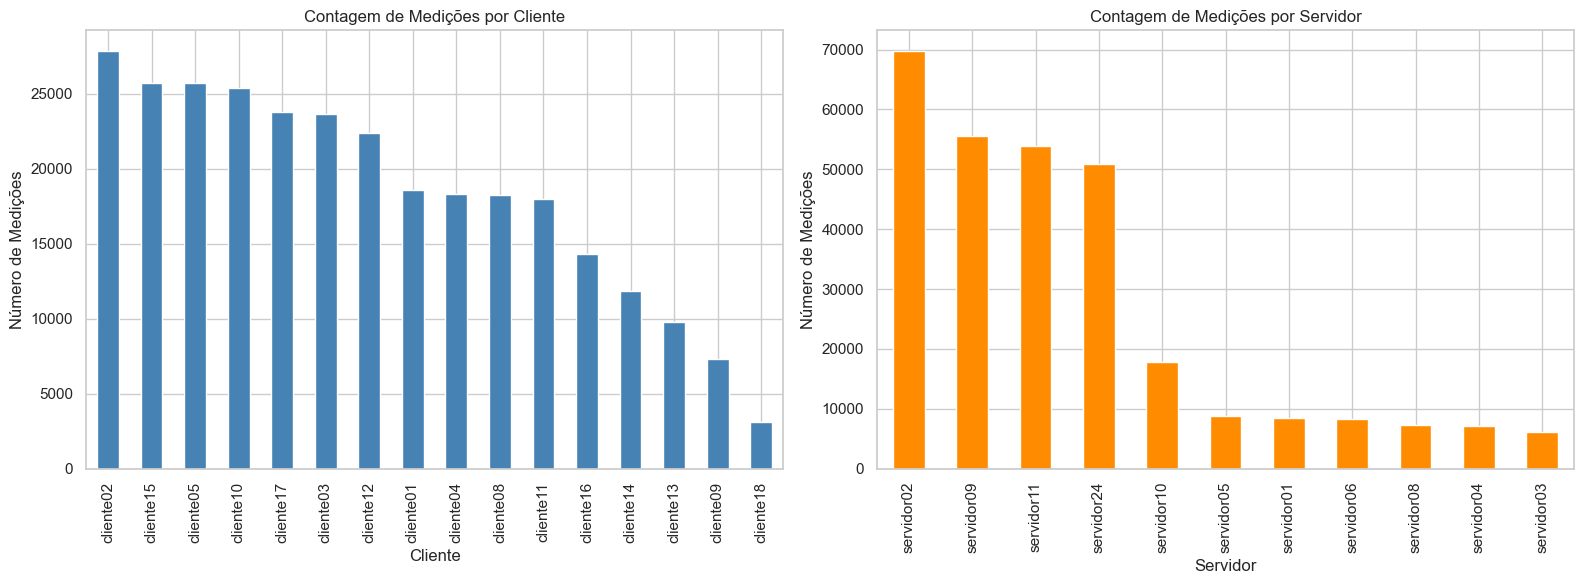

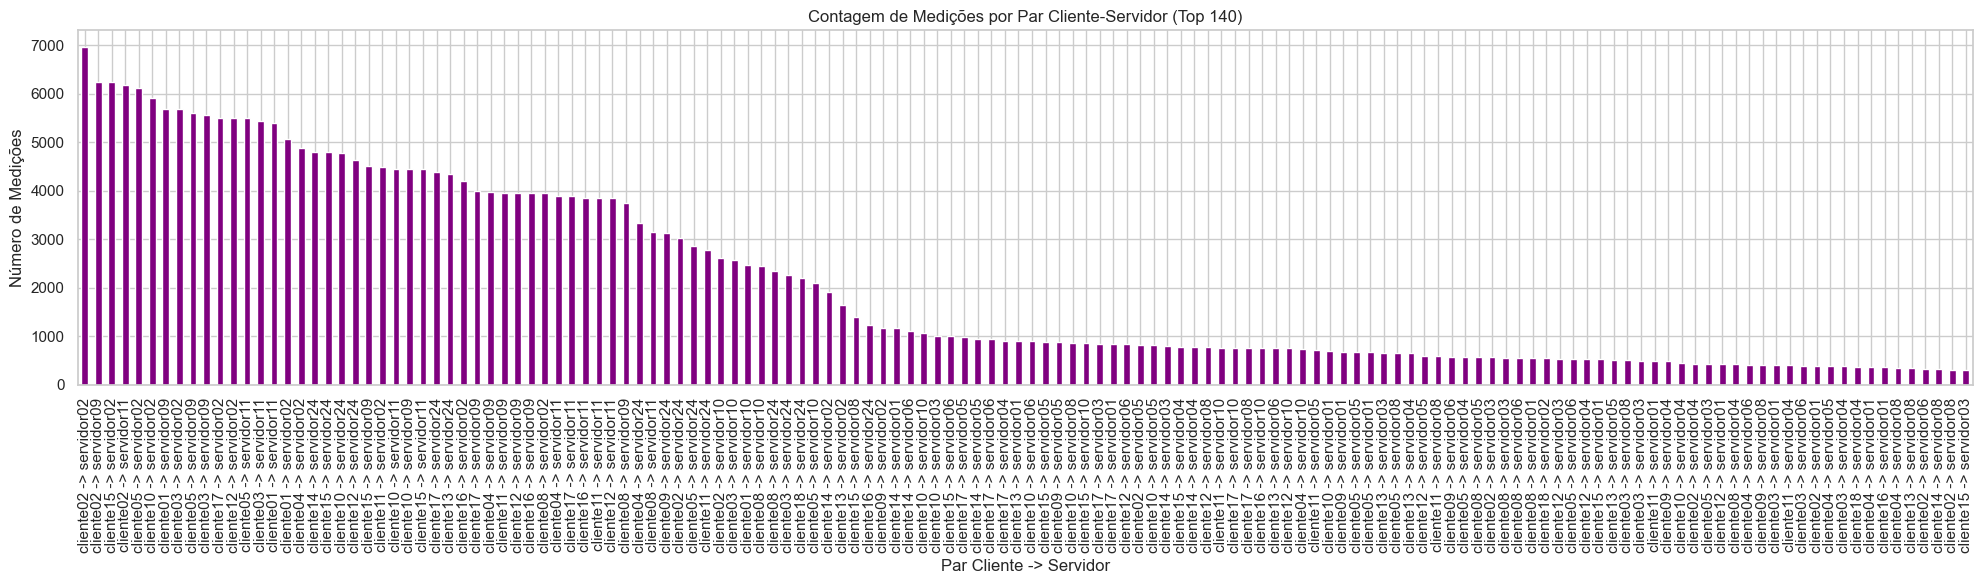

In [32]:
# Contagens Gerais
total_medicoes = len(df_clean)
num_clientes = df_clean['client_name'].nunique()
num_servidores = df_clean['server_name'].nunique()
num_pares = df_clean['client_server_pair'].nunique()

print(f"Total de medições: {total_medicoes}")
print(f"Total de clientes distintos: {num_clientes}")
print(f"Total de servidores distintos: {num_servidores}")

num_pares = df_clean['client_server_pair'].nunique()
print(f"Total de pares cliente-servidor distintos: {num_pares}")

# Somatório dos segmentos por par
blocos_por_par = df_clean.groupby('client_server_pair')['id_bloco'].nunique().sort_values(ascending=False)
blocos_total = blocos_por_par.sum()
print(f"Total de segmentos identificados: {blocos_total}")

# Máximo de segmentos em um par cliente-servidor
max_segmentos = blocos_por_par.max()
print(f"Máximo de segmentos para um par cliente-servidor: {max_segmentos}")

# Média de segmentos por par cliente-servidor
media_segmentos = blocos_por_par.mean()
print(f"Média de segmentos por par cliente-servidor: {media_segmentos:.2f}")

# Distribuição por Cliente e Servidor
medicoes_por_cliente = df_clean['client_name'].value_counts()
medicoes_por_servidor = df_clean['server_name'].value_counts()

# Plotagem em Gráficos de Barras
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico de Clientes
medicoes_por_cliente.plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Contagem de Medições por Cliente')
axes[0].set_ylabel('Número de Medições')
axes[0].set_xlabel('Cliente')
axes[0].tick_params(axis='x', rotation=90)

# Gráfico de Servidores
medicoes_por_servidor.plot(kind='bar', ax=axes[1], color='darkorange')
axes[1].set_title('Contagem de Medições por Servidor')
axes[1].set_ylabel('Número de Medições')
axes[1].set_xlabel('Servidor')
axes[1].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

medicoes_por_par = df_clean['client_server_pair'].value_counts()

import matplotlib.pyplot as plt

plt.figure(figsize=(20, 6))
medicoes_por_par.plot(kind='bar', color='purple')
plt.title(f'Contagem de Medições por Par Cliente-Servidor (Top {len(medicoes_por_par)})')
plt.xlabel('Par Cliente -> Servidor')
plt.ylabel('Número de Medições')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [33]:
# Identificação das duplicatas
duplicatas = df_clean.duplicated(subset=['client_server_pair', 'timestamp'], keep=False)
df_duplicadas = df_clean[duplicatas].sort_values(by=['client_server_pair', 'timestamp']).dropna()
uuids_duplicados = df_duplicadas['test_uuid'].unique()

# Agregação e resumo
pares_com_duplicatas = df_duplicadas.groupby('client_server_pair').size()
nomes_pares = pares_com_duplicatas[pares_com_duplicatas > 1].index.tolist()

# 5. Print organizado (Refinado conforme seu pedido)
print("="*60)
print(f"RESUMO DE DUPLICATAS")
print("="*60)
print(f"Total de pares com registros colidindo: {len(pares_com_duplicatas)}")
print(f"Total absoluto de linhas duplicadas:    {len(df_duplicadas)}")
print(f"Total de UUIDs únicos colidindo:        {len(uuids_duplicados)}")

print("="*60)

RESUMO DE DUPLICATAS
Total de pares com registros colidindo: 0
Total absoluto de linhas duplicadas:    0
Total de UUIDs únicos colidindo:        0


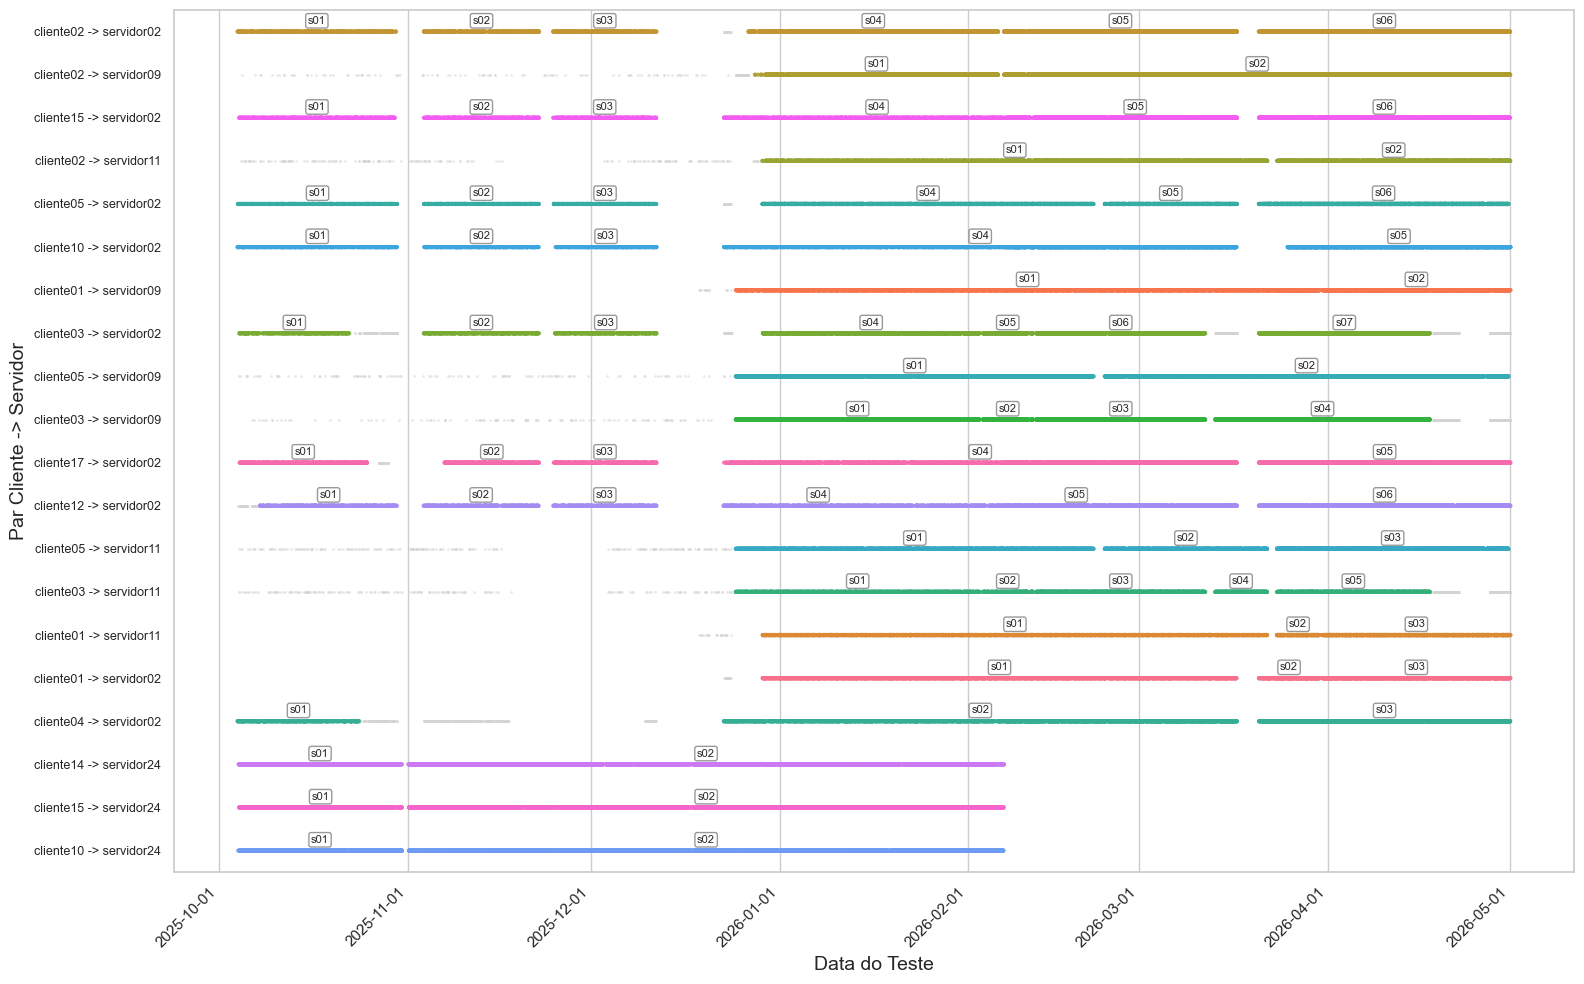

In [39]:
# 1. Cria a lista com os PARES ordenados pelo volume de uso
ordem_pares = df_clean['client_server_pair'].value_counts().index[:20]
df_clean = df_clean[df_clean['client_server_pair'].isin(ordem_pares)].copy()

# Modificações para a tese
# ordem_pares = ordem_pares[:20]
data_inicio = pd.to_datetime('2025-10-04', utc=True)
df_2 = df[df['timestamp'] >= data_inicio].copy()

sns.set_theme(style="whitegrid")
plt.figure(figsize=(16, 10)) 

# 2. Usando STRIPPLOT por Par
sns.stripplot(
    data=df_2,
    x='timestamp', 
    y='client_server_pair',
    color='lightgray',
    size=2,
    alpha=0.5,
    order=ordem_pares,
    jitter=False,
    zorder=1
)
sns.stripplot(
    data=df_clean,
    x='timestamp', 
    y='client_server_pair',
    hue='client_server_pair',
    palette="husl",
    size=3,
    alpha=0.8,
    legend=False,
    order=ordem_pares,
    jitter=False,
    zorder=2
)

# --- ADIÇÃO DAS CAIXAS DE TEXTO PARA OS SEGMENTOS ---

# Mapeia cada par para sua posição numérica no eixo Y (0, 1, 2...) baseada na ordem do plot
y_mapping = {par: i for i, par in enumerate(ordem_pares)}

# Agrupa por par e por bloco
for (par, bloco), group in df_clean.groupby(['client_server_pair', 'id_bloco']):
    
    # Encontra o meio do segmento no eixo X (data/hora)
    x_min = group['timestamp'].min()
    x_max = group['timestamp'].max()
    x_center = x_min + (x_max - x_min) / 2
    
    # Pega a posição Y correspondente ao par
    y_pos = y_mapping[par]
    
    # Adiciona a caixa de texto
    plt.text(
        x=x_center, 
        y=y_pos - 0.25, # O -0.25 desloca a caixa um pouco para cima para não cobrir a linha
        s=f"s{int(bloco):02d}", 
        fontsize=8,
        ha='center', # Centraliza o texto no eixo X
        va='center', # Centraliza o texto no eixo Y
        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="gray", alpha=0.8), # Cria a caixa visual
        zorder=3
    )
# -----------------------------------------------------

# plt.title('Linha do Tempo de Atividade: Medições por Par Cliente-Servidor', fontsize=18, pad=20)
plt.xlabel('Data do Teste', fontsize=14)
plt.ylabel('Par Cliente -> Servidor', fontsize=14)

# Formatação do eixo X (Tempo)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(fontsize=9) # Fonte menor para os nomes dos pares

plt.tight_layout()
plt.show()

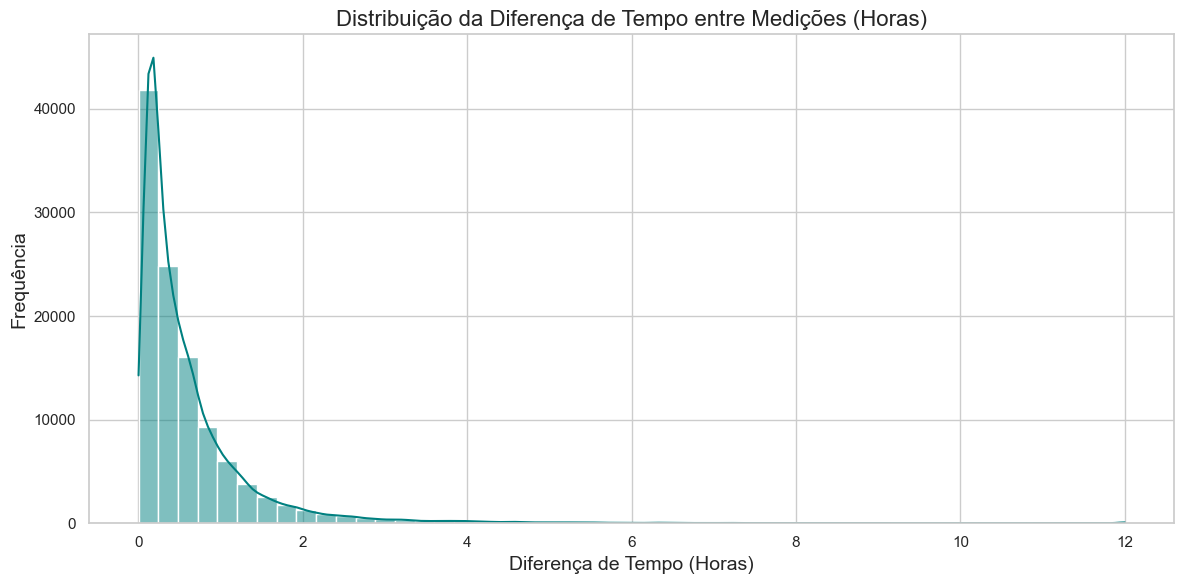

In [35]:
df_hist = df_clean['delta_tempo_horas'].copy().dropna()

# clip para evitar outliers extremos
lower_bound = 0
upper_bound = 12
df_hist = df_hist.clip(lower=lower_bound, upper=upper_bound)

# histograma da diferença de tempo entre medições para o dataset todo
plt.figure(figsize=(12, 6))
sns.histplot(df_hist, bins=50, kde=True, color='teal')
plt.title('Distribuição da Diferença de Tempo entre Medições (Horas)', fontsize=16)
plt.xlabel('Diferença de Tempo (Horas)', fontsize=14)
plt.ylabel('Frequência', fontsize=14)
plt.tight_layout()
plt.show()

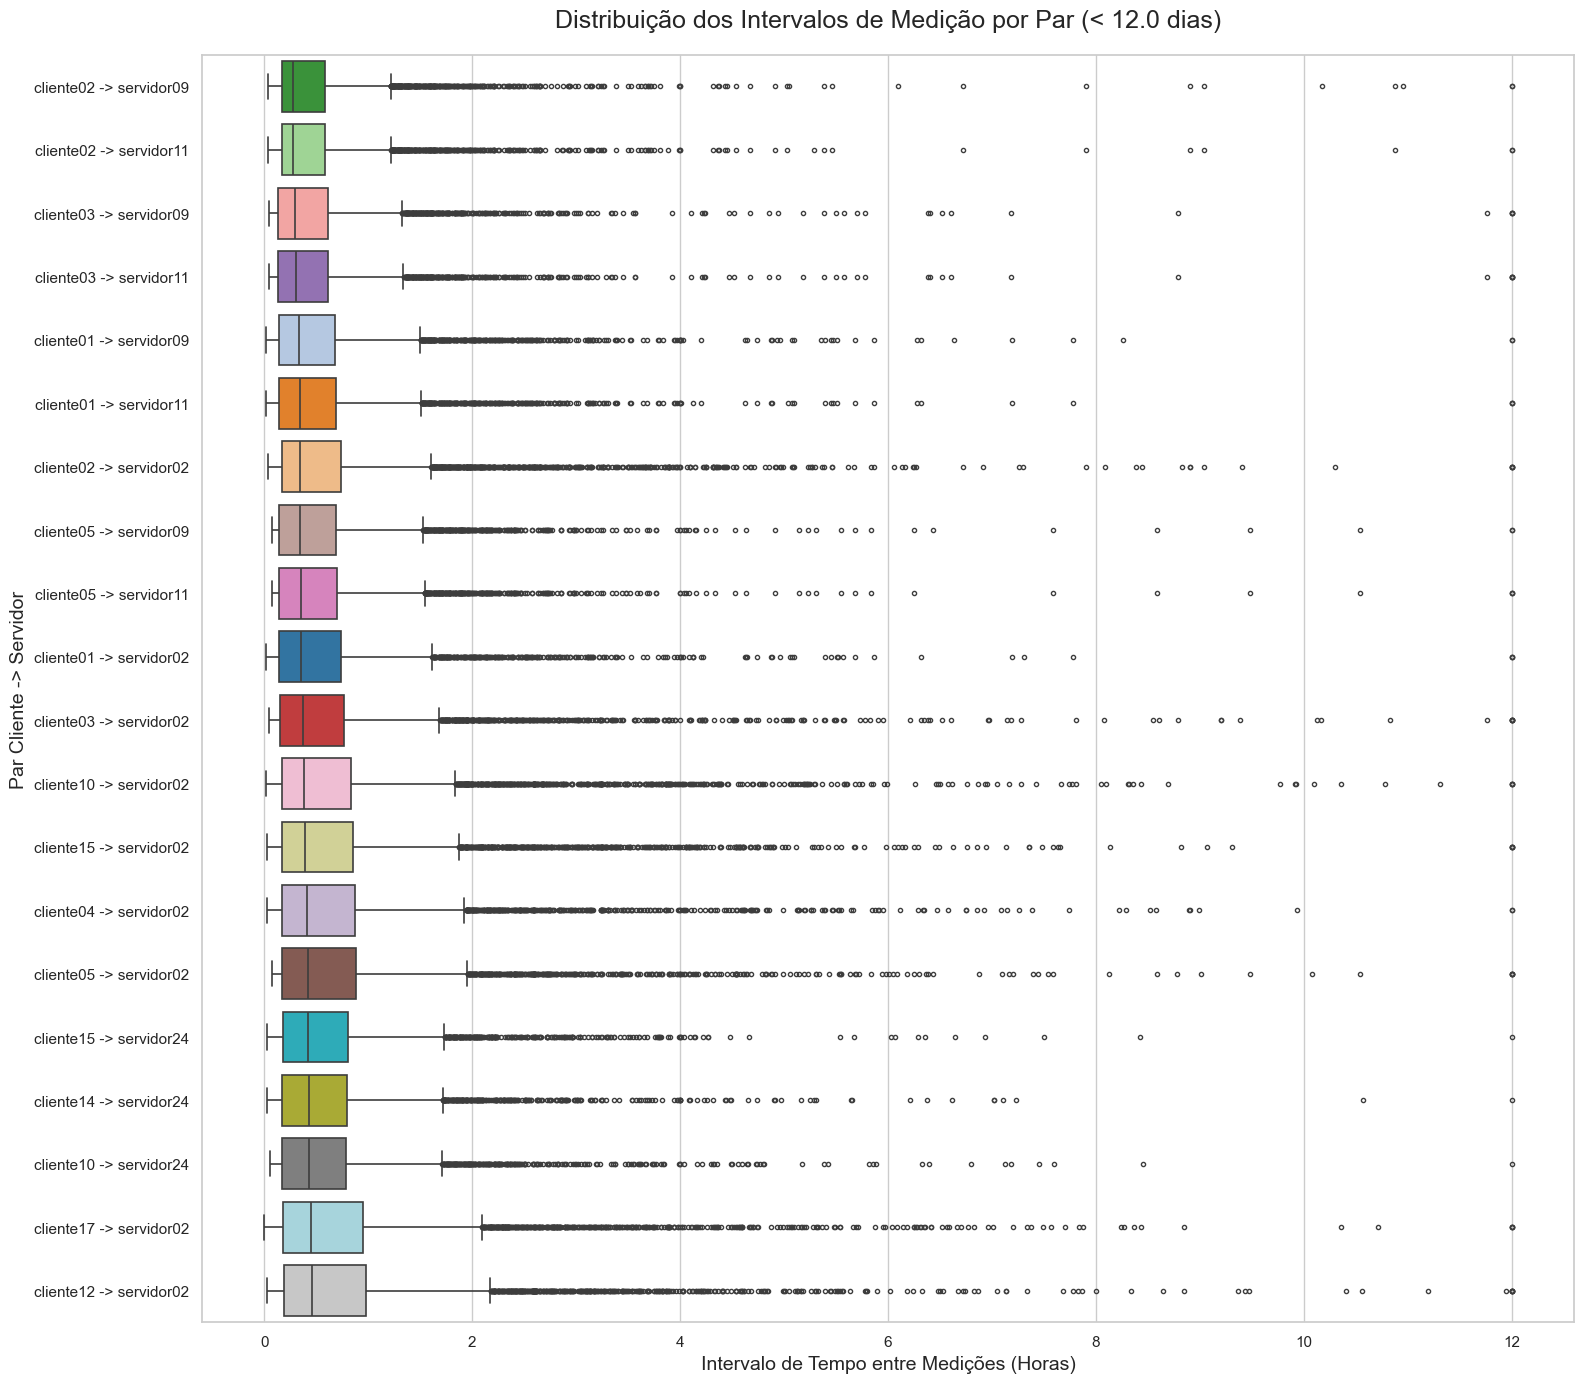

In [36]:
# rdenar o gráfico pela mediana do intervalo para melhor visualização
ordem_pares = df_clean.groupby('client_server_pair')['delta_tempo_horas'].median().sort_values().index

#criar copia do dataframe para plotagem
df_intervalos = df_clean.copy()

# clipar os valores de delta_tempo_horas em 1 e 99 percentil
lim_inf = 0
lim_sup = 12.0
df_intervalos['delta_tempo_horas'] = df_intervalos['delta_tempo_horas'].clip(lower=lim_inf, upper=lim_sup)


# Plotar o boxplot
sns.set_theme(style="whitegrid")
plt.figure(figsize=(16, 14))

sns.boxplot(
    data=df_intervalos,
    y='client_server_pair',
    x='delta_tempo_horas',
    hue='client_server_pair', 
    legend=False,             
    order=ordem_pares,
    palette='tab20',
    fliersize=3,
    linewidth=1.2
)

plt.title(f'Distribuição dos Intervalos de Medição por Par (< {limite_horas} dias)', fontsize=18, pad=20)
plt.xlabel('Intervalo de Tempo entre Medições (Horas)', fontsize=14)
plt.ylabel('Par Cliente -> Servidor', fontsize=14)

plt.tight_layout()
plt.show()

### Distribuição de Dados e Detecção de Outliers

Esta etapa analisa o comportamento estatístico individual de cada métrica de rede. A utilização de **Histogramas** permite visualizar o formato da distribuição dos dados (identificando assimetrias, como a cauda longa comum em métricas de *throughput* e latência). Simultaneamente, os **Boxplots** fornecem um resumo visual da dispersão, destacando a mediana, os quartis e, crucialmente, os *outliers* (valores atípicos que podem representar anomalias reais da rede ou erros de medição a serem tratados antes da aplicação do modelo de *Changepoint Detection*).

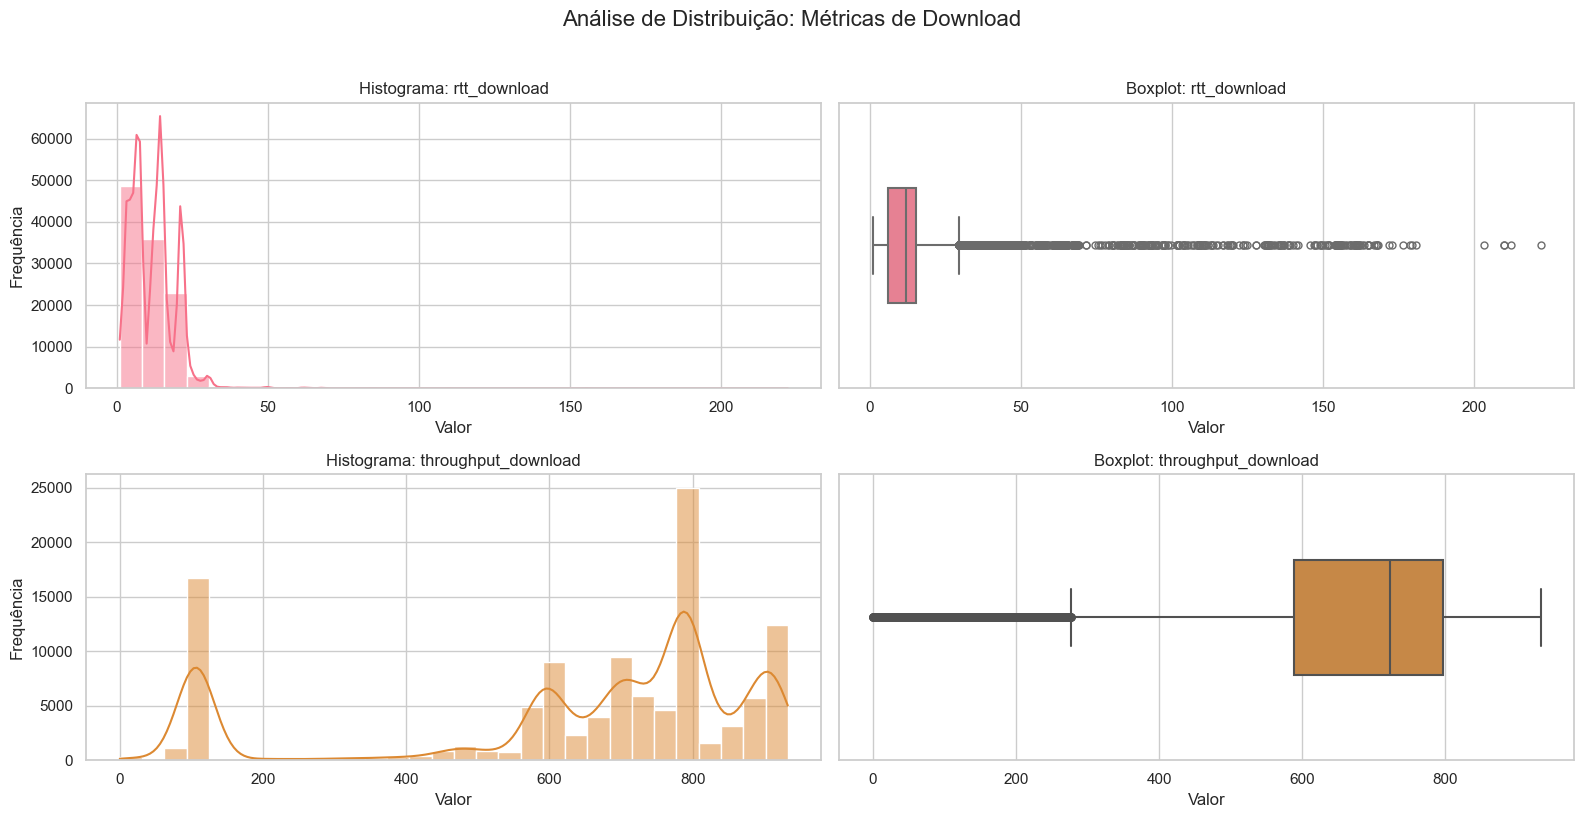

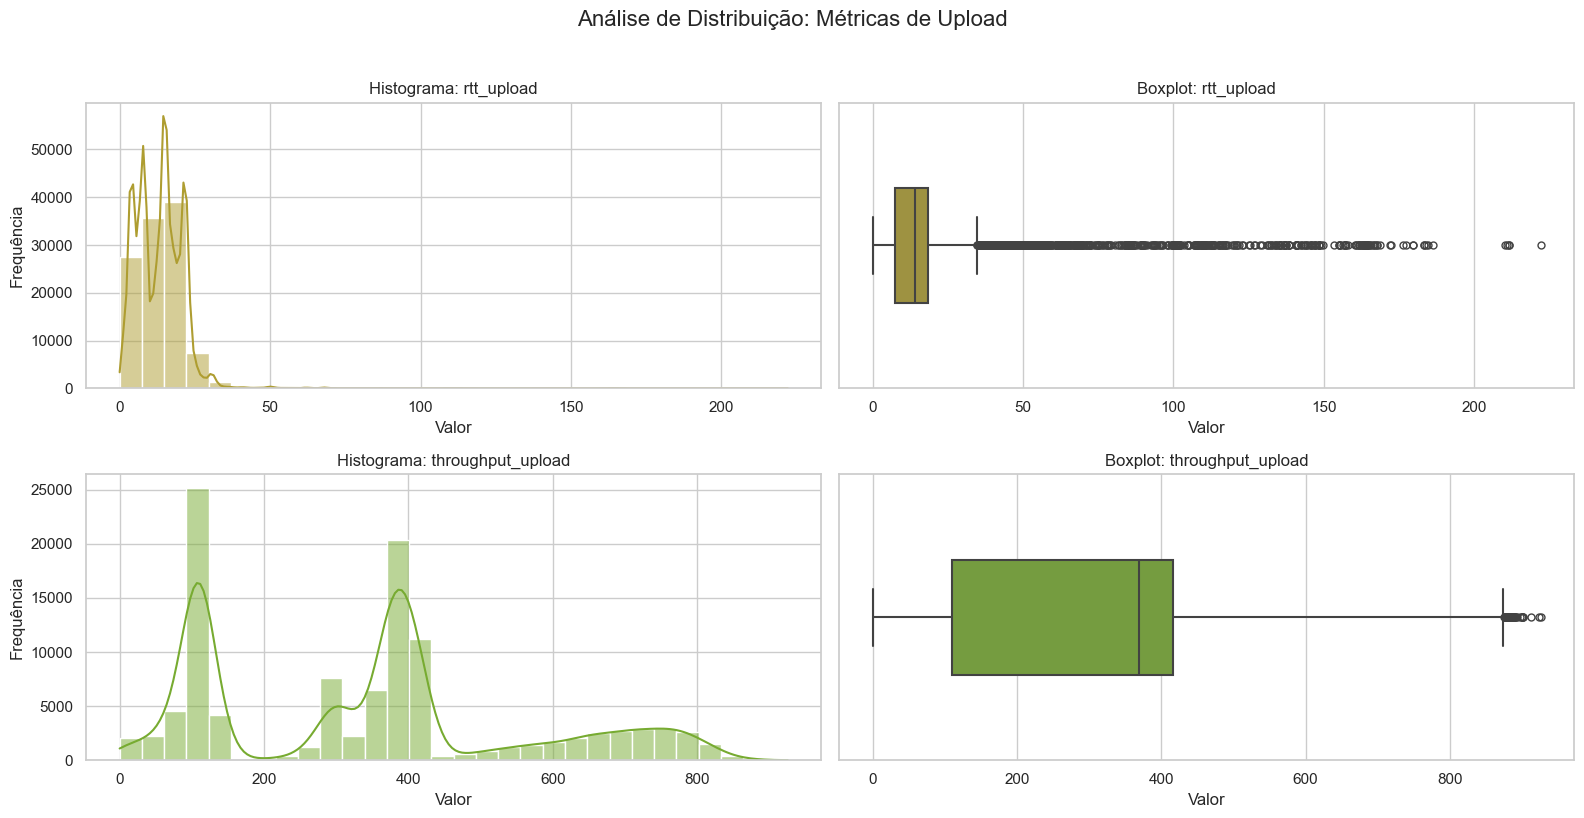

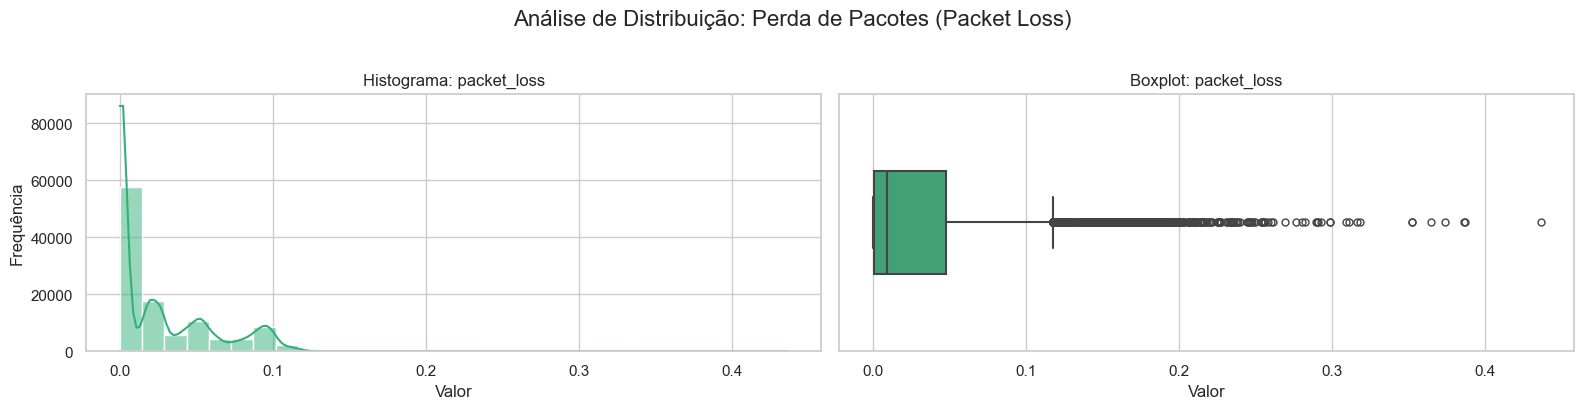

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

# Função auxiliar para gerar os gráficos padronizados por grupo sem tratamento interno
def plot_grupo_metricas(metrics, titulo, color_offset):
    metrics_exist = [m for m in metrics if m in df_clean.columns]
    if not metrics_exist:
        return
        
    fig, axes = plt.subplots(nrows=len(metrics_exist), ncols=2, figsize=(16, 4 * len(metrics_exist)))
    palette = sns.color_palette("husl", 10)
    
    for i, col in enumerate(metrics_exist):
        # Tratar a indexação dos axes (se for só 1 linha, axes é 1D)
        if len(metrics_exist) == 1:
            ax_hist = axes[0]
            ax_box = axes[1]
        else:
            ax_hist = axes[i, 0]
            ax_box = axes[i, 1]
            
        color = palette[color_offset + i]
        
        # Histograma com KDE (direto da coluna, sem dropna)
        sns.histplot(df_clean[col], kde=True, color=color, ax=ax_hist, bins=30)
        ax_hist.set_title(f'Histograma: {col}')
        ax_hist.set_xlabel('Valor')
        ax_hist.set_ylabel('Frequência')
        
        # Boxplot (direto da coluna, sem dropna)
        sns.boxplot(
            x=df_clean[col], 
            color=color, 
            width=0.4, 
            fliersize=5, 
            linewidth=1.5,
            ax=ax_box
        )
        ax_box.set_title(f'Boxplot: {col}')
        ax_box.set_xlabel('Valor')

    plt.suptitle(titulo, fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

# 1. Figura Exclusiva para Download
plot_grupo_metricas(
    ['rtt_download', 'throughput_download'], 
    'Análise de Distribuição: Métricas de Download', 
    color_offset=0
)

# 2. Figura Exclusiva para Upload
plot_grupo_metricas(
    ['rtt_upload', 'throughput_upload'], 
    'Análise de Distribuição: Métricas de Upload', 
    color_offset=2
)

# 3. Figura Exclusiva para Packet Loss
plot_grupo_metricas(
    ['packet_loss'], 
    'Análise de Distribuição: Perda de Pacotes (Packet Loss)', 
    color_offset=4
)

In [38]:
# estatisticas descritivas de df_clean 
df_clean[['rtt_download', 'throughput_download', 'rtt_upload', 'throughput_upload', 'packet_loss']].describe()

,rtt_download,throughput_download,rtt_upload,throughput_upload,packet_loss
count,111788.000000,111788.000000,111788.000000,111788.000000,111788.000000
mean,12.159776,637.816485,13.510975,342.076600,0.026847
std,8.938228,263.822952,9.359049,219.455860,0.033980
min,1.000000,0.000000,0.000000,0.004152,0.000000
25%,6.082000,589.098017,7.486000,110.327804,0.000855
50%,12.000000,723.031211,14.148500,369.176741,0.009696
75%,15.461000,797.205322,18.412000,415.752822,0.047639
max,222.105000,932.799724,222.023000,925.487900,0.436379
